========== DATASET ==========
   Student_ID        Name   Age  Gender Course  Department  Attendance  \
0        1019  Student_19  20.0    Male    BCA   Marketing        82.8   
1        1058  Student_58  22.0  Female    BBA          IT        83.2   
2        1001  Student_01  25.0  Female  B.Com   Marketing        68.2   
3        1044  Student_44  24.0  Female    BCA   Marketing        91.0   
4        1006  Student_06  23.0    Male    BCA  Operations        57.3   

   Internal_Marks  Assignment_Score  Final_Marks  Study_Hours  \
0            70.0              88.0         80.0          3.0   
1            94.0              93.0         40.0          8.5   
2            72.0              58.0         63.0          5.3   
3            79.0              71.0         49.0          NaN   
4            59.0              83.0         84.0          5.1   

  Placement_Status   Salary  
0           Placed  35000.0  
1           Placed      NaN  
2       Not Placed  40000.0  
3           Pl

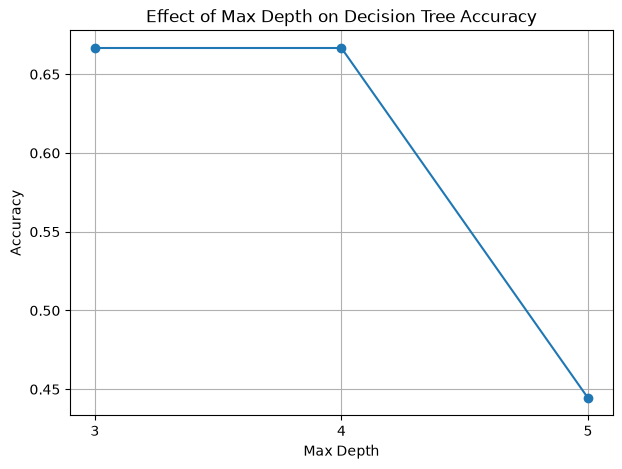

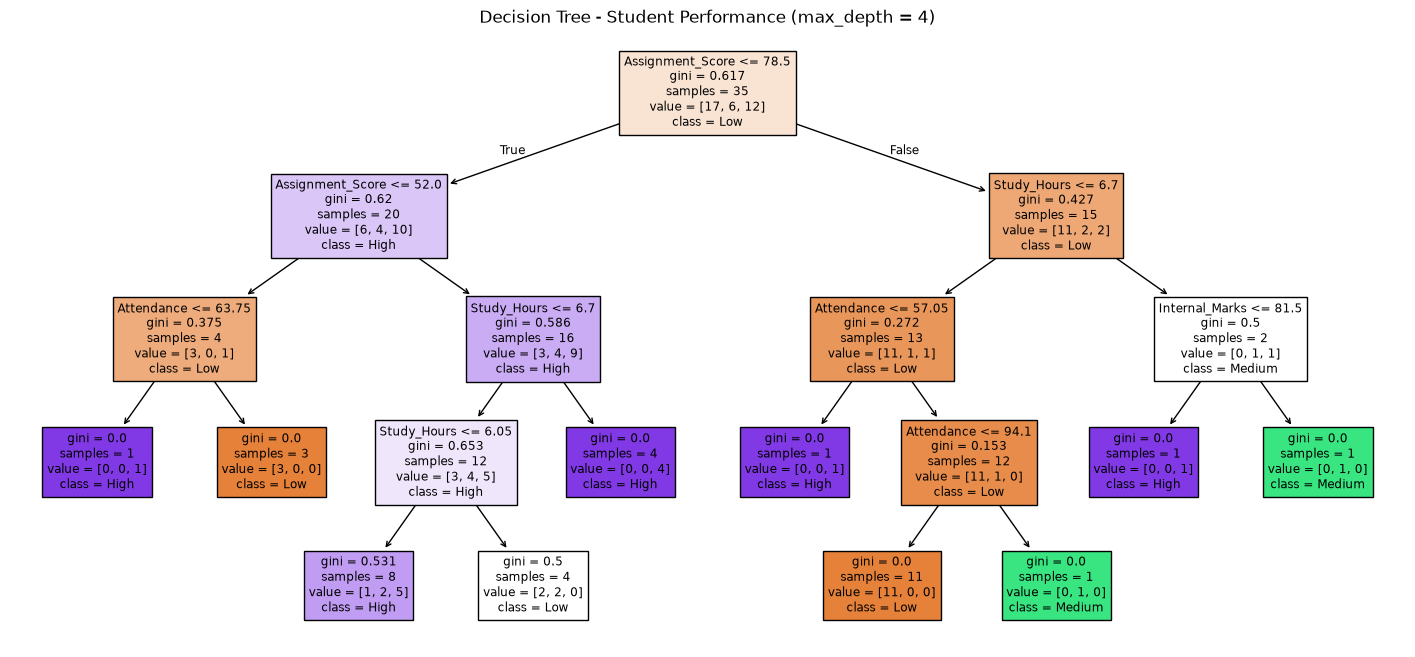


========== FEATURE IMPORTANCE ==========
            Feature  Importance
0        Attendance    0.328239
3       Study_Hours    0.324856
2  Assignment_Score    0.281759
1    Internal_Marks    0.065147

CONCLUSION

A Decision Tree Classification model was developed to predict
student performance using Attendance, Internal Marks,
Assignment Score and Study Hours.

The model was trained with max_depth values of 3, 4 and 5.
The accuracy of each model was compared to understand the
effect of tree depth on model performance.

A smaller tree is simpler and easier to understand, while
increasing the depth allows the model to learn more detailed
patterns from the data.



In [3]:
# ============================================================
# ASSIGNMENT 1: DECISION TREE - STUDENT PERFORMANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# Load dataset
data = pd.read_csv("student_data (1).csv")

print("========== DATASET ==========")
print(data.head())

print("\n========== COLUMNS ==========")
print(data.columns.tolist())

# Select required columns
data = data[
    [
        "Attendance",
        "Internal_Marks",
        "Assignment_Score",
        "Study_Hours",
        "Final_Marks"
    ]
]

# Remove missing values
data = data.dropna()

print("\n========== DATA AFTER CLEANING ==========")
print(data.head())

# Features
X = data[
    [
        "Attendance",
        "Internal_Marks",
        "Assignment_Score",
        "Study_Hours"
    ]
]

# Target
y = data["Final_Marks"]

# Convert Final Marks into performance categories
# Low = below 50
# Medium = 50 to 69
# High = 70 and above

y = pd.cut(
    y,
    bins=[0, 49, 69, 100],
    labels=["Low", "Medium", "High"]
)

print("\n========== PERFORMANCE CATEGORIES ==========")
print(y.value_counts())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================================
# TRAIN DECISION TREE WITH DIFFERENT DEPTHS
# ============================================================

results = []

for depth in [3, 4, 5]:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    results.append({
        "Max Depth": depth,
        "Accuracy": accuracy
    })

    print("\n--------------------------------")
    print("Max Depth:", depth)
    print("Accuracy:", round(accuracy, 4))

# ============================================================
# COMPARISON
# ============================================================

comparison = pd.DataFrame(results)

print("\n========== COMPARISON ==========")
print(comparison)

# ============================================================
# ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    comparison["Max Depth"],
    comparison["Accuracy"],
    marker="o"
)

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Effect of Max Depth on Decision Tree Accuracy")

plt.xticks([3, 4, 5])
plt.grid(True)

plt.show()

# ============================================================
# DISPLAY DECISION TREE FOR MAX DEPTH = 4
# ============================================================

model_4 = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model_4.fit(X_train, y_train)

plt.figure(figsize=(18, 8))

plot_tree(
    model_4,
    feature_names=X.columns,
    class_names=["Low", "Medium", "High"],
    filled=True
)

plt.title("Decision Tree - Student Performance (max_depth = 4)")

plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_4.feature_importances_
})

print("\n========== FEATURE IMPORTANCE ==========")
print(importance.sort_values(
    by="Importance",
    ascending=False
))

# ============================================================
# CONCLUSION
# ============================================================

print("""
============================================================
CONCLUSION
============================================================

A Decision Tree Classification model was developed to predict
student performance using Attendance, Internal Marks,
Assignment Score and Study Hours.

The model was trained with max_depth values of 3, 4 and 5.
The accuracy of each model was compared to understand the
effect of tree depth on model performance.

A smaller tree is simpler and easier to understand, while
increasing the depth allows the model to learn more detailed
patterns from the data.
""")

Electronics Industry Dataset:
   Temperature  Power_Consumption
0           20                100
1           25                110
2           30                120
3           35                135
4           40                145
5           45                160
6           50                175
7           55                185
8           60                200
9           65                215

Predicted Power Consumption:
[ 96.54545455 109.42424242 122.3030303  135.18181818 148.06060606
 160.93939394 173.81818182 186.6969697  199.57575758 212.45454545]

Predicted Power Consumption at 52°C: 178.97

Regression Equation:
Power Consumption = 45.03 + 2.58 * Temperature

Mean Squared Error: 3.88
R2 Score: 0.9972


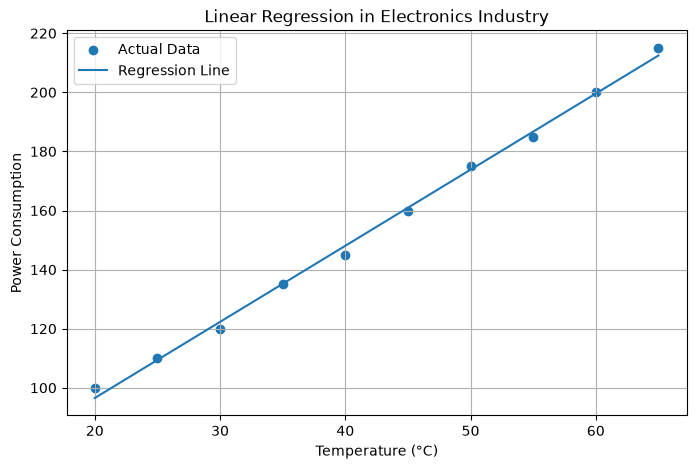


CONCLUSION:
Linear Regression was used to predict the power consumption
of an electronic device based on operating temperature.
The model learned the relationship between temperature and
power consumption and was also used to predict consumption
at a new temperature.



In [4]:
# ============================================================
# ASSIGNMENT 2: LINEAR REGRESSION - ELECTRONICS INDUSTRY
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create sample electronics industry data
data = {
    "Temperature": [20, 25, 30, 35, 40, 45, 50, 55, 60, 65],
    "Power_Consumption": [100, 110, 120, 135, 145, 160, 175, 185, 200, 215]
}

df = pd.DataFrame(data)

print("Electronics Industry Dataset:")
print(df)

# Feature and target
X = df[["Temperature"]]
y = df["Power_Consumption"]

# Create and train Linear Regression model
model = LinearRegression()

model.fit(X, y)

# Predictions
y_pred = model.predict(X)

print("\nPredicted Power Consumption:")
print(y_pred)

# Predict power consumption for a new temperature
new_temperature = pd.DataFrame({
    "Temperature": [52]
})

predicted_power = model.predict(new_temperature)

print(
    "\nPredicted Power Consumption at 52°C:",
    round(predicted_power[0], 2)
)

# Regression equation
print("\nRegression Equation:")
print(
    "Power Consumption =",
    round(model.intercept_, 2),
    "+",
    round(model.coef_[0], 2),
    "* Temperature"
)

# Model evaluation
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("\nMean Squared Error:", round(mse, 2))
print("R2 Score:", round(r2, 4))

# Visualization
plt.figure(figsize=(8, 5))

plt.scatter(
    X["Temperature"],
    y,
    label="Actual Data"
)

plt.plot(
    X["Temperature"],
    y_pred,
    label="Regression Line"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Power Consumption")
plt.title("Linear Regression in Electronics Industry")
plt.legend()
plt.grid(True)

plt.show()

print("""
CONCLUSION:
Linear Regression was used to predict the power consumption
of an electronic device based on operating temperature.
The model learned the relationship between temperature and
power consumption and was also used to predict consumption
at a new temperature.
""")

Customer Dataset:
    Annual_Income  Spending_Score
0              20              20
1              22              25
2              25              22
3              28              30
4              30              28
5              60              60
6              65              65
7              68              62
8              70              70
9              75              68
10             85              85
11             88              90
12             90              88
13             92              92
14             95              95

========== CUSTOMER CLUSTERS ==========
    Annual_Income  Spending_Score  Cluster
0              20              20        2
1              22              25        2
2              25              22        2
3              28              30        2
4              30              28        2
5              60              60        0
6              65              65        0
7              68              62        0
8         

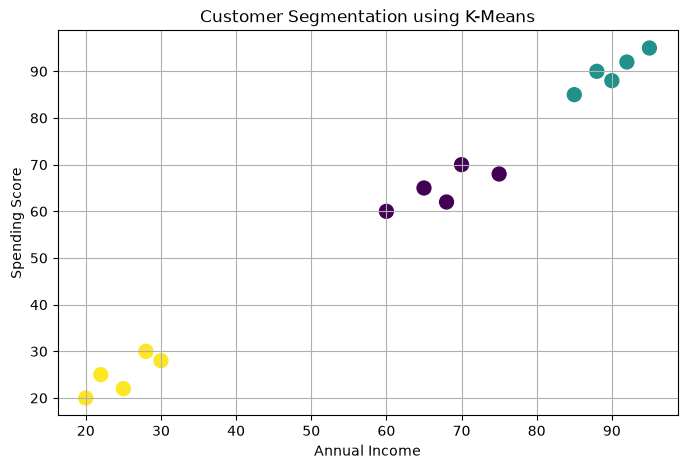


CONCLUSION:
K-Means Clustering was used as an unsupervised learning
algorithm to divide customers into three groups based on
annual income and spending score. No target variable was
provided to the model. The algorithm automatically found
groups of similar customers.



In [5]:
# ============================================================
# ASSIGNMENT 3: UNSUPERVISED LEARNING - K-MEANS CLUSTERING
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

# Create customer dataset
data = {
    "Annual_Income": [
        20, 22, 25, 28, 30,
        60, 65, 68, 70, 75,
        85, 88, 90, 92, 95
    ],

    "Spending_Score": [
        20, 25, 22, 30, 28,
        60, 65, 62, 70, 68,
        85, 90, 88, 92, 95
    ]
}

df = pd.DataFrame(data)

print("Customer Dataset:")
print(df)

# Select features
X = df[["Annual_Income", "Spending_Score"]]

# Create K-Means model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Train the model
kmeans.fit(X)

# Add cluster number to dataset
df["Cluster"] = kmeans.labels_

print("\n========== CUSTOMER CLUSTERS ==========")
print(df)

# Display cluster centers
print("\n========== CLUSTER CENTERS ==========")
print(kmeans.cluster_centers_)

# Visualize clusters
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"],
    s=100
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.grid(True)

plt.show()

print("""
CONCLUSION:
K-Means Clustering was used as an unsupervised learning
algorithm to divide customers into three groups based on
annual income and spending score. No target variable was
provided to the model. The algorithm automatically found
groups of similar customers.
""")